# Mathematical Modeling

------------

## A. Set up card model

Enumerated attributes:

* Color
    * Red
    * Purple
    * Green
* Count
    * 1
    * 2
    * 3
* Fill
    * Solid
    * Striped
    * Open
* Shape
    * Capsule
    * Diamond
    * Squiggle

I think the best way is to number them instead of keeping string lables, and this is for two reasons. 

1. Pragmatic: indexing arrays is easy with numbers.
2. Semantic: All attributes are equal in function and importance.

In [135]:
import numpy as np
import random
from pprint import pprint
from itertools import combinations, permutations
from tqdm import tqdm
from collections import defaultdict, Counter, deque
import matplotlib.pyplot as plt
from datetime import datetime
import copy
import math


from visualize_cards import Card

1. establish the cardspace

In [9]:
size = 3
grid = np.array([[[[i for i in range(size)] for _ in range(size)] for _ in range(size)] for _ in range(size)])
grid

array([[[[0, 1, 2],
         [0, 1, 2],
         [0, 1, 2]],

        [[0, 1, 2],
         [0, 1, 2],
         [0, 1, 2]],

        [[0, 1, 2],
         [0, 1, 2],
         [0, 1, 2]]],


       [[[0, 1, 2],
         [0, 1, 2],
         [0, 1, 2]],

        [[0, 1, 2],
         [0, 1, 2],
         [0, 1, 2]],

        [[0, 1, 2],
         [0, 1, 2],
         [0, 1, 2]]],


       [[[0, 1, 2],
         [0, 1, 2],
         [0, 1, 2]],

        [[0, 1, 2],
         [0, 1, 2],
         [0, 1, 2]],

        [[0, 1, 2],
         [0, 1, 2],
         [0, 1, 2]]]])

2. Function to detect if any set of coords is a set

There are only three states, so no need to get fancy with the linalg.

In [10]:
def check_colinearity(a, b, c):
    lengths = [len(set([x[dim] for x in (a, b, c)])) for dim in range(4)]
    if 2 in lengths:
        return False, 0
    else:
        return True, lengths.count(1)

check_hashmap =  {frozenset({0}), frozenset({1}), frozenset({2}), frozenset({0, 1, 2})}

def hash_colinearity(a, b, c):
    for i in range(4):
        if frozenset((a[i], b[i], c[i])) in check_hashmap:
            continue
        else:
            return False
    return True


In [11]:
tests = [[[0, 0, 0, 0], [0, 0, 0, 1], [0, 0, 0, 2]], 
         [[0, 0, 0, 0], [0, 0, 0, 1], [0, 0, 0, 1]],
         [[1, 1, 1, 1], [0, 0, 0, 0], [2, 2, 2, 2]],
         [[0, 1, 2, 0], [1, 1, 2, 1], [2, 1, 2, 2]], 
         [[0, 1, 2, 0], [1, 1, 2, 1], [2, 2, 2, 2]]]

answers = [True, False, True, True, False]

for t, a in zip(tests, answers):
    # if (outcome := check_colinearity(*t))[0] == a:
    if (outcome := hash_colinearity(*t)) == a:
        print('pass', outcome)
    else:
        print('fail', outcome)

pass True
pass False
pass True
pass True
pass False


## B. How many sets of 12 don't have any sets?

for any given 3 cards amongst any given 12 cards, 

In [12]:
choices = [0, 1, 2]

for _ in range(4):
    random_dims = [random.choice(choices) for _ in range(4)]
    print(random_dims)
    random_card = Card(random_dims)
    pprint(random_card.__dict__)
    
    for i in random_card.vis:
        print(i)

[2, 0, 0, 2]
{'color': 'red',
 'fill': 'empty',
 'number': 3,
 'shape': 'capsule',
 'vis': ['\x1b┌───┐\x1b',
         '\x1b│(☐)│\x1b',
         '\x1b│(☐)│\x1b',
         '\x1b│(☐)│\x1b',
         '\x1b└───┘\x1b']}
┌───┐
│(☐)│
│(☐)│
│(☐)│
└───┘
[2, 0, 1, 2]
{'color': 'red',
 'fill': 'stripe',
 'number': 3,
 'shape': 'capsule',
 'vis': ['\x1b┌───┐\x1b',
         '\x1b│(▥)│\x1b',
         '\x1b│(▥)│\x1b',
         '\x1b│(▥)│\x1b',
         '\x1b└───┘\x1b']}
┌───┐
│(▥)│
│(▥)│
│(▥)│
└───┘
[0, 2, 1, 0]
{'color': 'green',
 'fill': 'stripe',
 'number': 1,
 'shape': 'diamond',
 'vis': ['\x1b┌───┐\x1b',
         '\x1b│   │\x1b',
         '\x1b│<▥>│\x1b',
         '\x1b│   │\x1b',
         '\x1b└───┘\x1b']}
┌───┐
│   │
│<▥>│
│   │
└───┘
[0, 0, 0, 1]
{'color': 'red',
 'fill': 'empty',
 'number': 1,
 'shape': 'squiggle',
 'vis': ['\x1b┌───┐\x1b',
         '\x1b│   │\x1b',
         '\x1b│╔☐╝│\x1b',
         '\x1b│   │\x1b',
         '\x1b└───┘\x1b']}
┌───┐
│   │
│╔☐╝│
│   │
└───┘


In [49]:
def display_grid(twelve):
    for row_idxs in [list(range(4)), list(range(4, 8)), list(range(8, 12))]:
        # print(row_idxs)
        print('' + '   '.join([f'{i}'.rjust(3) for i in row_idxs]))
        cards = list(map(lambda x: Card(twelve[x]), row_idxs))
        for line in range(5):
            line = [f'{card.vis[line]} ' for card in cards]
            print(''.join(line))

def count_sets(twelve):
    sets = 0
    for comb in combinations(range(12), 3):
        cards = [twelve[c] for c in comb]
        set_found = hash_colinearity(*cards)
        if set_found:
            sets += 1
    return sets

def combo_counter(n, k): 
    def recur_factorial(a, total=1):
        if a == 0:
            return 1
        elif a > 1:
            return recur_factorial(a-1, total*a)
        elif a == 1:
            return total
    
    n_fac = recur_factorial(n)
    k_fac = recur_factorial(k)

    return n_fac // (k_fac * recur_factorial((n - k)))

def print_cards_in_row(cards):
    for idx in range(5):
        line = [f'{card.vis[idx]} ' for card in cards]
        line = ''.join(line)
        print(line)

In [50]:
random_12 = {j: [random.choice(choices) for _ in range(4)] for j in range(12)}
# pprint(random_12)

display_grid(random_12)

counts = count_sets(random_12)
print(f'\n{counts} Sets Found:')
for comb in combinations(range(12), 3):
    cards = [random_12[c] for c in comb]
    set_found, count = check_colinearity(*cards)
    if set_found:
        cards = list(map(lambda x: Card(random_12[x]), comb))
        print_cards_in_row(cards)
        print(f'monoattributes: {count}')


  0     1     2     3
┌───┐ ┌───┐ ┌───┐ ┌───┐ 
│   │ │   │ │   │ │╔☐╝│ 
│(■)│ │╔■╝│ │╔■╝│ │   │ 
│   │ │   │ │   │ │╔☐╝│ 
└───┘ └───┘ └───┘ └───┘ 
  4     5     6     7
┌───┐ ┌───┐ ┌───┐ ┌───┐ 
│<☐>│ │   │ │   │ │<▥>│ 
│<☐>│ │(▥)│ │<■>│ │   │ 
│<☐>│ │   │ │   │ │<▥>│ 
└───┘ └───┘ └───┘ └───┘ 
  8     9    10    11
┌───┐ ┌───┐ ┌───┐ ┌───┐ 
│(■)│ │(■)│ │<■>│ │<☐>│ 
│   │ │(■)│ │   │ │<☐>│ 
│(■)│ │(■)│ │<■>│ │<☐>│ 
└───┘ └───┘ └───┘ └───┘ 

4 Sets Found:
┌───┐ ┌───┐ ┌───┐ 
│   │ │   │ │   │ 
│(■)│ │╔■╝│ │<■>│ 
│   │ │   │ │   │ 
└───┘ └───┘ └───┘ 
monoattributes: 2
┌───┐ ┌───┐ ┌───┐ 
│   │ │(■)│ │(■)│ 
│(■)│ │   │ │(■)│ 
│   │ │(■)│ │(■)│ 
└───┘ └───┘ └───┘ 
monoattributes: 2
┌───┐ ┌───┐ ┌───┐ 
│<☐>│ │   │ │<▥>│ 
│<☐>│ │<■>│ │   │ 
│<☐>│ │   │ │<▥>│ 
└───┘ └───┘ └───┘ 
monoattributes: 1
┌───┐ ┌───┐ ┌───┐ 
│   │ │<▥>│ │<☐>│ 
│<■>│ │   │ │<☐>│ 
│   │ │<▥>│ │<☐>│ 
└───┘ └───┘ └───┘ 
monoattributes: 1


I wonder how low it will take to iterate through every set of 12... 

In [21]:
every_possible_card = [] #81 cards, not too much RAM
for a in range(3):
    for b in range(3):
        for c in range(3):
            for d in range(3):
                every_possible_card.append([a, b, c, d])

In [ ]:
total_boards = combo_counter(81, 12)
print(f'Total Boards: {total_boards}')

start_time = datetime.now()
set_counter = defaultdict(int)
trials = int(1e6)
for _ in tqdm(range(trials)):
    combo = random.sample(every_possible_card, 12)
# for combo in tqdm(combinations(every_possible_card, 12)):
    n_sets = count_sets(combo)
    set_counter[n_sets] += 1
    # if counter % int(1e9) == 0:
    #     print(f'{100*(counter/total_boards)}%' )
taken_time = datetime.now() - start_time

outcomes = {k: 100*(v/trials) for k, v in set_counter.items()}
pprint(outcomes)


sampled_pct = trials / total_boards

print('PURE PYTHON IMPLEMENTATION:')
print(f'Tested {sampled_pct*100}% of the total space, taking {taken_time.total_seconds()} seconds.')
print(f'At this rate, sampling the full space would take {(taken_time.total_seconds() / sampled_pct) / (365.2425 * 24 * 60 * 60)} years.')

Total Boards: 70724320184700


100%|██████████| 1000000/1000000 [02:28<00:00, 6734.37it/s]

{0: 3.2178999999999998,
 1: 14.5211,
 2: 26.119999999999997,
 3: 27.2409,
 4: 18.029600000000002,
 5: 8.0045,
 6: 2.3109,
 7: 0.4678,
 8: 0.0726,
 9: 0.013300000000000001,
 10: 0.0013,
 11: 9.999999999999999e-05}
PURE PYTHON IMPLEMENTATION:
Tested 1.4139407736807529e-06% of the total space, taking 148.51021 seconds.
At this rate, sampling the full space would take 332.83580881756376 years.


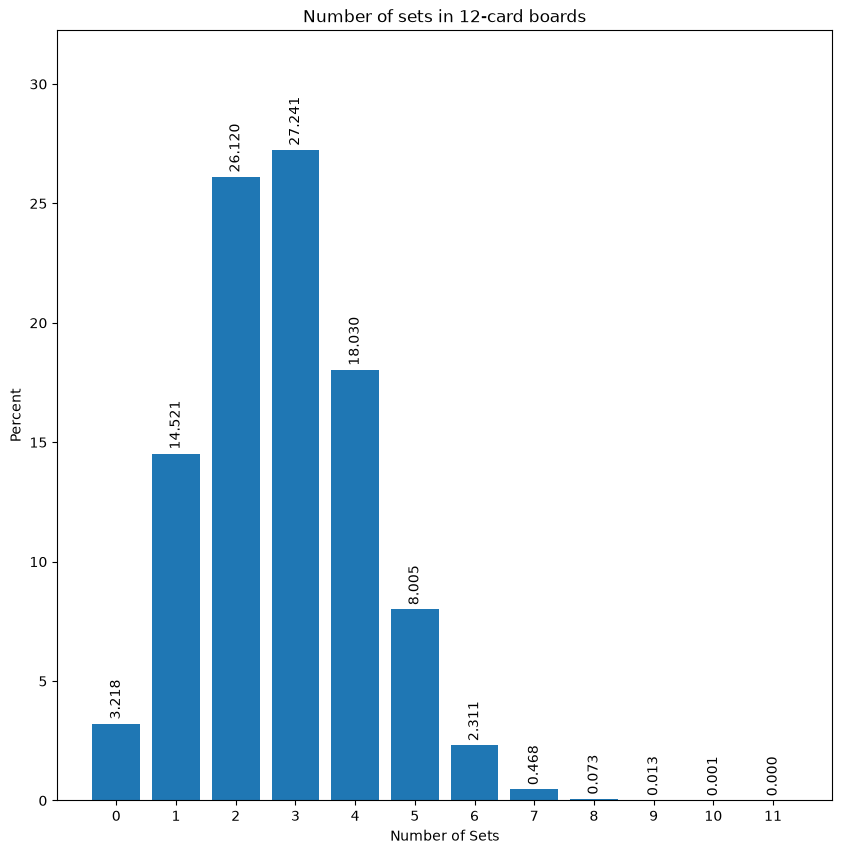

In [16]:
# sort by number of sets
items = sorted(outcomes.items())

labels = np.array([k for k, v in items], dtype=float)
sizes = np.array([v for k, v in items], dtype=float)

fig, ax = plt.subplots(figsize=(10, 10))
bars = ax.bar(labels, sizes)

# labels on each bar
ax.bar_label(bars, labels=[f"{v:.3f}" for v in sizes], padding=3, rotation=90)
ax.set_ylim(0, max(sizes)+5)
ax.set_xticks(labels)
ax.set_title("Number of sets in 12-card boards")
ax.set_xlabel("Number of Sets")
ax.set_ylabel("Percent")

plt.show()

so of 12-card boards, there are about 3.2% of them will NOT have a single set. The peak is between 2-3 sets per 12-card board, 

Whaaat if I try it in C?

In [17]:
byte_count = 707_243_201_847 * 12 * 4  #unique_boards * Cards per board * attributes per card
TB_count = byte_count/(1000**4)
print(f'Assuming a 4 byte int, the total search space would take {TB_count} TB')

Assuming a 4 byte int, the total search space would take 33.947673688656 TB


Okay this is kind of absurd. Is there a more performant way of checking for colinearity? 

a, b, and c, are arrays of 4 ints, e.g. [0, 1, 2, 0]

(all logic below is written in Python for readability)

#### 1. initial approach (pure python):
```
def check_colinearity(a, b, c):
    common_dims = [len(set([x[dim] for x in (a, b, c)])) for dim in range(4)]
    if 2 in lengths:
        return False, 0
    else:
        return True, common_dims.count(1)
```
I would like to keep the functionality of counting how many attributes are identical for all three sets, ideally.

#### 2. Current approach (C):
```
def c_colinearity(a, b, c):
    for i in range(4):
        if sum([a[i] + b[i] + c[i]]) % 3 == 0:
            continue
        else:
            return False
    return True
```
Elegant trick with checking for mod 3. 

#### 3. Hash approach: 
```
check_hashmap =  {frozenset({0}), frozenset({1}), frozenset({2}), frozenset({0, 1, 2})}

def hash_colinearity(a, b, c):
    for i in range(4):
        if frozenset((a[i], b[i], c[i])) in check_hashmap:
            continue
        else:
            return False
    return True
```
probably the fastest python way of doing it? This got me from a estimated 5.5 yrs to 2 years. 

#### 4. difference approach:

```
def c_colinearity(a, b, c):
    for i in range(4):
        sorted_vals = sorted(a[i], b[i], c[i]) #uses powersort? idk about sorting algos
        if sorted_vals[1] - sorted_vals[0] == sorted_vals[2] - sorted_vals[1]:
            continue
        else:
            return False
    return True
```
Would be flexible enough to account for values outside of (0, 1, 2), but that's not needed for this project. 

#### 5. array sum approach:

```
de arr_colinearity(a, b, c):
    common_attr = 0
    for i in range(4):
        idxs = [0, 0, 0]
        idxs[a[i]] = 1 ; idxs[b[i]] = 1 ; idxs[c[i]] = 1
        if sum(idxs) == 2:
            return False
        elif sum(idxs) == 1:
            common_attr += 1
    return True, common_attr
```

#### 6. Tree based approach:

Enumerate all sets into dicts for lookup
    There are 1080 sets, but we will need them in all iterative orders so 1080*6 = 6048 where you can index them as all_sets[a][b] == c
loop through, navigating through the tree and static lookup. 
This should be faster since you're dividing the amount of potential work by 4. 

In [ ]:
!gcc -O3 tree_search_boards.c -o tree_search_boards

total_boards = combo_counter(81, 12)
print(f'Total Boards: {total_boards}')
trials = int(1e7)
board_size = 12

outfile = f"tree_search_{trials}_{board_size}.txt"

start_time = datetime.now()
!./tree_search_boards {trials} {board_size} > {outfile}
taken_time = datetime.now() - start_time

sampled_pct = trials / total_boards

print('CLANG IMPLEMENTATION:')
print(f'Tested {sampled_pct*100}% of the total space for board size {board_size}, taking {taken_time.total_seconds()} seconds.')
print(f'At this rate, sampling the full space would take {(taken_time.total_seconds() / sampled_pct) / (24* 60 * 60)} days.')

with open(outfile) as f:
    output = f.read()

print(output)

Total Boards: 70724320184700
CLANG IMPLEMENTATION:
Tested 1.4139407736807528e-05% of the total space for board size 12, taking 2.278008 seconds.
At this rate, sampling the full space would take 186.47056386031028 days.
5: 2252200
6: 3215074
7: 1974960
8: 1314820
9: 845464
10: 317898
11: 12600
12: 46152
13: 18240
14: 2592



# C. How many 15-card boards don't have sets?

oh boy. Let's see how long combo(81, 15) takes. 

In [ ]:
!gcc -O3 tree_search_boards.c -o tree_search_borads

total_boards = combo_counter(81, 15)
print(f'Total Boards: {total_boards}')
trials = int(1e7)
board_size = 15

start_time = datetime.now()
!./tree_search_boards {trials} {board_size}
taken_time = datetime.now() - start_time

sampled_pct = trials / total_boards

print('CLANG IMPLEMENTATION:')
print(f'Tested {sampled_pct*100}% of the total space for board size {board_size}, taking {taken_time.total_seconds()} seconds.')
print(f'At this rate, sampling the full space would take {(taken_time.total_seconds() / sampled_pct) / (365.2425*24 * 60 * 60)} years.')

Total Boards: 8144022047817960
12: 914577
13: 1906669
14: 3240244
15: 2541168
16: 1115869
17: 182941
18: 79632
19: 13524
20: 1296
21: 3456
22: 576
23: 48
CLANG IMPLEMENTATION:
Tested 1.2278945146863048e-07% of the total space for board size 15, taking 3.747998 seconds.
At this rate, sampling the full space would take 96.72600302835845 years.


Oh no

## D. Monoattribute Distribution by set

In [ ]:
actual_sets = []
for a, b, c in permutations(every_possible_card, 3):
    is_set = True
    for idx in range(4):
        if (a[idx] + b[idx] + c[idx]) % 3  == 0:
            continue
        else:
            is_set = False
            break
    if is_set:
        actual_sets.append((a, b, c))
print(f'All actual sets: {len(actual_sets)}')

All actual sets: 6480
([0, 0, 0, 0], [0, 0, 0, 1], [0, 0, 0, 2])


In [58]:
def count_monoattr(a, b, c):
    count = 0
    for idx in range(4):
        if len({a[idx], b[idx], c[idx]}) == 1:
            count += 1
    return count

In [60]:
#spot check
for _ in range(5):
    cards = random.choice(actual_sets)
    cards_obj = list(map(Card, cards))
    print_cards_in_row(cards_obj)
    print(f'monoattributes: {count_monoattr(*cards)}')

┌───┐ ┌───┐ ┌───┐ 
│╔☐╝│ │<☐>│ │(☐)│ 
│   │ │   │ │   │ 
│╔☐╝│ │<☐>│ │(☐)│ 
└───┘ └───┘ └───┘ 
monoattributes: 2
┌───┐ ┌───┐ ┌───┐ 
│(■)│ │(▥)│ │   │ 
│(■)│ │   │ │(☐)│ 
│(■)│ │(▥)│ │   │ 
└───┘ └───┘ └───┘ 
monoattributes: 2
┌───┐ ┌───┐ ┌───┐ 
│   │ │╔☐╝│ │<▥>│ 
│(■)│ │╔☐╝│ │   │ 
│   │ │╔☐╝│ │<▥>│ 
└───┘ └───┘ └───┘ 
monoattributes: 1
┌───┐ ┌───┐ ┌───┐ 
│(☐)│ │(▥)│ │   │ 
│   │ │(▥)│ │(■)│ 
│(☐)│ │(▥)│ │   │ 
└───┘ └───┘ └───┘ 
monoattributes: 2
┌───┐ ┌───┐ ┌───┐ 
│   │ │╔▥╝│ │(■)│ 
│<☐>│ │   │ │(■)│ 
│   │ │╔▥╝│ │(■)│ 
└───┘ └───┘ └───┘ 
monoattributes: 0


In [63]:
attr_count = defaultdict(int)
for cards in actual_sets:
    attr_count[count_monoattr(*cards)] += 1
print(attr_count)
print({k: f'{(100*v/len(actual_sets))}%' for k, v in attr_count.items()})

defaultdict(<class 'int'>, {3: 648, 2: 1944, 1: 2592, 0: 1296})
{3: '10.0%', 2: '30.0%', 1: '40.0%', 0: '20.0%'}


In [69]:
len(list(combinations(range(4), 2)))

6

Well, that's conclusive. Soooooo facinating. 

## E. Min board size to always have a set

I think the best way to do this is with aggressive trimming. So let's say we begin with 

[0, 0, 0, 0] and [0, 0, 0, 1]

the set that would be disqualified is [0, 0, 0, 2]

so then I can include [0, 0, 1, 1]

bot then that disqualifies [0, 0, 2, 2] and [0, 0, 2, 1]

so 

* 2 cards excludes 1, total 3
* 3 cards excludes 3, total 6
* 4 cards excludes 6, total 10

aka for any n, the number excluded = len(combinations(range(n), 2))

This means that n is the max where {board size} + {excluded count} <= {total cards}

    n + combo_counter(n, 2) <= 81



In [71]:
n = 2
while True:
    claimed = n + combo_counter(n, 2)
    print(n, combo_counter(n, 2))
    if claimed > 81:
        print(n-1)
        break
    else:
        n += 1

2 1
3 3
4 6
5 10
6 15
7 21
8 28
9 36
10 45
11 55
12 66
13 78
12


This says the answer is 12, but that definitely isn't true, since sometimes 15-card boards don't have sets. 12 exlcudes 66, but if 78 are claimed, what happens to the remaining 3? 

In [99]:
def find_third(a, b):
    c = []
    for i in range(4):
        if a[i] == b[i]:
            c.append(a[i])
        else: 
            c.append([j for j in (0, 1, 2) if j not in (a[i], b[i])][0])
    return c

In [113]:
board = [every_possible_card[0], every_possible_card[1]]

def max_without_set(board):
    while True:
        excluded = []
        for a, b in combinations(board, 2):
            excluded.append(find_third(a, b))
        for card in every_possible_card:
            alive = False
            if card not in board and card not in excluded:
                board.append(card)
                alive = True
                break
        if not alive:
            break
    return board

board = max_without_set(board)
print(f'largest board without set has {len(board)} cards:')
pprint(board)
print(f'sets: {count_sets(board)}')


largest board without set has 16 cards:
[[0, 0, 0, 0],
 [0, 0, 0, 1],
 [0, 0, 1, 0],
 [0, 0, 1, 1],
 [0, 1, 0, 0],
 [0, 1, 0, 1],
 [0, 1, 1, 0],
 [0, 1, 1, 1],
 [1, 0, 0, 0],
 [1, 0, 0, 1],
 [1, 0, 1, 0],
 [1, 0, 1, 1],
 [1, 1, 0, 0],
 [1, 1, 0, 1],
 [1, 1, 1, 0],
 [1, 1, 1, 1]]
sets: 0


So that makes sense, you can't have any sets if you have zero of a certain state. The max without sets is 16, which means the min to always have a set is 17. 

In [123]:
for _ in range(5):
    board = max_without_set(random.sample(every_possible_card, 2))
    print(len(board), count_sets(board))


18 0
17 0
16 0
17 0
18 0


WHAT???? Why is it sometimes 18???

I guess this sort of makes sense? So thinking dimensionally, if I had [0, 0, 0, 1] and [0, 0, 0, 0], these cards are spacially very close together. If I spead out these starting points, then the possibility space is probably different.

SO 

1. does that mean there's a correlation between euclidian distance between starting points and the max without a set?

2. for any two starting cards, is the answer always the same? 

In [125]:
def get_euclidian_distance(a, b):
    return math.sqrt((a[0] + b[0])**2 + (a[1] + b[1])**2 + (a[2] + b[2])**2 + (a[3] + b[3])**2) 

In [129]:
euclidian_dists = [] ; board_sizes = []
for a, b in combinations(every_possible_card, 2):
    board = max_without_set(random.sample(every_possible_card, 2))
    euclidian_dists.append(get_euclidian_distance(a, b))
    board_sizes.append(len(board))
print(euclidian_dists)
print(board_sizes)

[1.0, 2.0, 1.0, 1.4142135623730951, 2.23606797749979, 2.0, 2.23606797749979, 2.8284271247461903, 1.0, 1.4142135623730951, 2.23606797749979, 1.4142135623730951, 1.7320508075688772, 2.449489742783178, 2.23606797749979, 2.449489742783178, 3.0, 2.0, 2.23606797749979, 2.8284271247461903, 2.23606797749979, 2.449489742783178, 3.0, 2.8284271247461903, 3.0, 3.4641016151377544, 1.0, 1.4142135623730951, 2.23606797749979, 1.4142135623730951, 1.7320508075688772, 2.449489742783178, 2.23606797749979, 2.449489742783178, 3.0, 1.4142135623730951, 1.7320508075688772, 2.449489742783178, 1.7320508075688772, 2.0, 2.6457513110645907, 2.449489742783178, 2.6457513110645907, 3.1622776601683795, 2.23606797749979, 2.449489742783178, 3.0, 2.449489742783178, 2.6457513110645907, 3.1622776601683795, 3.0, 3.1622776601683795, 3.605551275463989, 2.0, 2.23606797749979, 2.8284271247461903, 2.23606797749979, 2.449489742783178, 3.0, 2.8284271247461903, 3.0, 3.4641016151377544, 2.23606797749979, 2.449489742783178, 3.0, 2.449

/tmp/ipykernel_144382/3627078718.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  plt.gca().set_yticklabels([int(x) for x in plt.gca().get_yticks()])


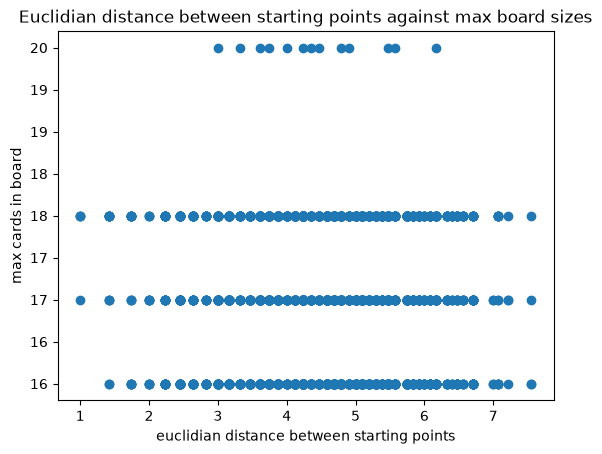

In [131]:
plt.scatter(euclidian_dists, board_sizes)
plt.gca().set_yticklabels([int(x) for x in plt.gca().get_yticks()])
plt.title('Euclidian distance between starting points against max board sizes')
plt.xlabel('euclidian distance between starting points')
plt.ylabel('max cards in board')
plt.show()

No, there is not really a correlation between starting distance and max cards in board.

I am also starting to suspect that a set of 2 cards alone does NOT determine the max. 

...Sigh... pathfinding. 

In [ ]:
card_tuples = [tuple(i) for i in every_possible_card]
q = deque([{card_tuples[0], card_tuples[1]}])

def dedupe_deque(q):
    seen = set()
    out = deque()

    for item in q:
        key = frozenset(item)

        if key not in seen:
            seen.add(key)
            out.append(item)

    return out

def get_possible_nexts(board):
    excluded = []
    for a, b in combinations(board, 2):
        excluded.append(find_third(a, b))
    possible_nexts = []
    for card in card_tuples:
        if card not in board and card not in excluded:
            possible_nexts.append(card)
    return possible_nexts

results = []
card_len = 2
while True:
    if not len(q):
        break
    board = q.popleft()
    if len(board) > card_len:
        card_len = len(board)
        print(card_len)
    # print(type(board))
    possible_nexts = get_possible_nexts(board)
    if not possible_nexts:
        print(len(board))
        results.append(len(board))
    else:
        for pn in possible_nexts:
            q.append(board|{pn})
    q = dedupe_deque(q)
print(results)

3
4
5


I guess this also has to be written in C?